In [2]:
import pandas as pd
import numpy as np

# ---------- helper: FRED series ----------
def read_fred_series(series_id, value_name):
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    df = pd.read_csv(url)
    df.columns = [c.strip() for c in df.columns]   # убрать пробелы
    date_col, val_col = df.columns[0], df.columns[1]  # 1-я колонка дата, 2-я значение
    df[date_col] = pd.to_datetime(df[date_col])
    df[val_col] = pd.to_numeric(df[val_col], errors="coerce")
    return df.rename(columns={date_col: "Date", val_col: value_name}).set_index("Date").sort_index()

# ---------- 1) USD/RUB (CBR XML) ----------
def cbr_usd_rub(start="01/01/2010", end="31/12/2022"):
    url = (
        "https://www.cbr.ru/scripts/XML_dynamic.asp"
        f"?date_req1={start}&date_req2={end}&VAL_NM_RQ=R01235"
    )
    df = pd.read_xml(url, encoding="windows-1251")
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
    df["usd_rub"] = df["Value"].str.replace(",", ".", regex=False).astype(float)
    return df[["Date", "usd_rub"]].set_index("Date").sort_index()

usd = cbr_usd_rub()

# ---------- 2) Key rate (CBR table) ----------
def cbr_key_rate(start="17.09.2013", end="31.12.2022"):
    url = (
        "https://www.cbr.ru/eng/hd_base/KeyRate/"
        f"?UniDbQuery.Posted=True&UniDbQuery.From={start}&UniDbQuery.To={end}"
    )
    kr = pd.read_html(url)[0].copy()
    kr.columns = ["date", "key_rate"]
    kr["date"] = pd.to_datetime(kr["date"], dayfirst=True)
    kr["key_rate"] = pd.to_numeric(kr["key_rate"], errors="coerce")
    return kr.set_index("date").sort_index()

key_rate = cbr_key_rate()

# ---------- 3) Brent oil + 4) Russia CPI (FRED) ----------
brent = read_fred_series("DCOILBRENTEU", "brent")
cpi   = read_fred_series("RUSCPIALLMINMEI", "cpi_index")

# ---------- 5) to monthly ----------
usd_m   = usd.resample("M").mean()
brent_m = brent.resample("M").mean()

# key rate: daily ffill -> month end value
key_m = key_rate.resample("D").ffill().resample("M").last()

# CPI already monthly, but keep month end
cpi_m = cpi.resample("M").last()

data = cpi_m.join([key_m, usd_m, brent_m], how="inner").dropna()

# ---------- 6) target: inflation YoY ----------
data["infl_yoy"] = data["cpi_index"] / data["cpi_index"].shift(12) - 1

# ---------- 7) lags/features ----------
for lag in [1,2,3,12]:
    data[f"infl_yoy_lag{lag}"] = data["infl_yoy"].shift(lag)

data["usd_rub_lag1"] = data["usd_rub"].shift(1)
data["brent_lag1"]   = data["brent"].shift(1)
data["key_rate_lag1"]= data["key_rate"].shift(1)

model_df = data.dropna().copy()

print("model_df shape:", model_df.shape)
print(model_df.tail(5))
print("\nColumns:", model_df.columns.tolist())

model_df shape: (79, 12)
            cpi_index  key_rate     usd_rub       brent  infl_yoy  \
2021-11-30   135.6291       7.5   72.698911   81.050000  0.084037   
2021-12-31   136.7413       8.5   73.769313   74.170476  0.083930   
2022-01-31   138.0950       8.5   76.594747   86.505238  0.087376   
2022-02-28   139.7107      20.0   77.169374   97.129000  0.091584   
2022-03-31   150.3470      20.0  103.470045  117.245217  0.166984   

            infl_yoy_lag1  infl_yoy_lag2  infl_yoy_lag3  infl_yoy_lag12  \
2021-11-30       0.081354       0.074081       0.066927        0.044235   
2021-12-31       0.084037       0.081354       0.074081        0.049124   
2022-01-31       0.083930       0.084037       0.081354        0.051946   
2022-02-28       0.087376       0.083930       0.084037        0.056664   
2022-03-31       0.091584       0.087376       0.083930        0.057821   

            usd_rub_lag1  brent_lag1  key_rate_lag1  
2021-11-30     71.450091   83.538095            7.5  
2

C:\Users\Admin\AppData\Local\Temp\ipykernel_28380\1514769261.py:46: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  usd_m   = usd.resample("M").mean()
C:\Users\Admin\AppData\Local\Temp\ipykernel_28380\1514769261.py:47: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  brent_m = brent.resample("M").mean()
C:\Users\Admin\AppData\Local\Temp\ipykernel_28380\1514769261.py:50: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  key_m = key_rate.resample("D").ffill().resample("M").last()
C:\Users\Admin\AppData\Local\Temp\ipykernel_28380\1514769261.py:53: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  cpi_m = cpi.resample("M").last()


Train period: 2015-09-30 -> 2020-11-30
Test period : 2020-12-31 -> 2022-03-31
Train size: 63 Test size: 16


,model,MAE,RMSE,R2
0,Baseline (lag1),0.008066,0.019272,0.496617
1,Ridge,0.048372,0.050953,-2.518580
2,HistGradientBoosting,0.014596,0.027358,-0.014360


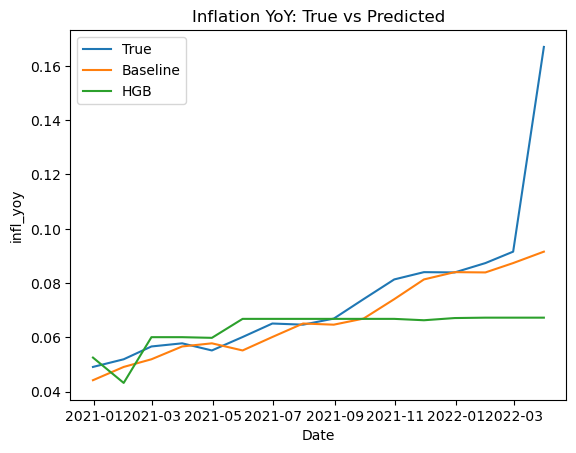

In [3]:
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor

# 1) X, y
target = "infl_yoy"
feature_cols = [c for c in model_df.columns if c != target]
X = model_df[feature_cols].copy()
y = model_df[target].copy()

# 2) Time split: последние 20% на тест
split_idx = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("Train period:", X_train.index.min().date(), "->", X_train.index.max().date())
print("Test period :", X_test.index.min().date(), "->", X_test.index.max().date())
print("Train size:", len(X_train), "Test size:", len(X_test))

# 3) Baseline: прогноз = infl_yoy_lag1 (то есть "как в прошлом месяце")
baseline_pred = model_df.loc[X_test.index, "infl_yoy_lag1"]
base_mae = mean_absolute_error(y_test, baseline_pred)
base_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
base_r2 = r2_score(y_test, baseline_pred)

# 4) Ridge
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train, y_train)
pred_ridge = ridge.predict(X_test)

ridge_mae = mean_absolute_error(y_test, pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, pred_ridge))
ridge_r2 = r2_score(y_test, pred_ridge)

# 5) HistGradientBoosting
hgb = HistGradientBoostingRegressor(random_state=42, max_depth=6, learning_rate=0.08, max_iter=400)
hgb.fit(X_train, y_train)
pred_hgb = hgb.predict(X_test)

hgb_mae = mean_absolute_error(y_test, pred_hgb)
hgb_rmse = np.sqrt(mean_squared_error(y_test, pred_hgb))
hgb_r2 = r2_score(y_test, pred_hgb)

# 6) Итоговая таблица
results = pd.DataFrame({
    "model": ["Baseline (lag1)", "Ridge", "HistGradientBoosting"],
    "MAE":   [base_mae, ridge_mae, hgb_mae],
    "RMSE":  [base_rmse, ridge_rmse, hgb_rmse],
    "R2":    [base_r2, ridge_r2, hgb_r2],
})
display(results)

# 7) График: факт vs прогноз
import matplotlib.pyplot as plt

plt.figure()
plt.plot(y_test.index, y_test.values, label="True")
plt.plot(y_test.index, baseline_pred.values, label="Baseline")
plt.plot(y_test.index, pred_hgb, label="HGB")
plt.title("Inflation YoY: True vs Predicted")
plt.xlabel("Date")
plt.ylabel("infl_yoy")
plt.legend()
plt.show()

In [4]:
import numpy as np
import pandas as pd

df2 = data.copy()

# новая цель: инфляция MoM
df2["infl_mom"] = df2["cpi_index"] / df2["cpi_index"].shift(1) - 1

# лаги MoM
for lag in [1,2,3,6,12]:
    df2[f"infl_mom_lag{lag}"] = df2["infl_mom"].shift(lag)

# изменения факторов (часто лучше уровней)
df2["usd_rub_pct"] = df2["usd_rub"].pct_change()
df2["brent_pct"] = df2["brent"].pct_change()
df2["key_rate_chg"] = df2["key_rate"].diff()

# лаги факторов
df2["usd_rub_pct_lag1"] = df2["usd_rub_pct"].shift(1)
df2["brent_pct_lag1"] = df2["brent_pct"].shift(1)
df2["key_rate_chg_lag1"] = df2["key_rate_chg"].shift(1)

model_df2 = df2.dropna().copy()
print(model_df2.shape)
model_df2.tail(3)

(79, 24)


,cpi_index,key_rate,usd_rub,brent,infl_yoy,infl_yoy_lag1,infl_yoy_lag2,infl_yoy_lag3,infl_yoy_lag12,usd_rub_lag1,...,infl_mom_lag2,infl_mom_lag3,infl_mom_lag6,infl_mom_lag12,usd_rub_pct,brent_pct,key_rate_chg,usd_rub_pct_lag1,brent_pct_lag1,key_rate_chg_lag1
2022-01-31,138.0950,8.5,76.594747,86.505238,0.087376,0.083930,0.084037,0.081354,0.051946,73.769313,...,0.0096,0.0111,0.003100,0.006700,0.038301,0.166303,0.0,0.014724,-0.084880,1.0
2022-02-28,139.7107,20.0,77.169374,97.129000,0.091584,0.087376,0.083930,0.084037,0.056664,76.594747,...,0.0082,0.0096,0.001700,0.007800,0.007502,0.122811,11.5,0.038301,0.166303,0.0
2022-03-31,150.3470,20.0,103.470045,117.245217,0.166984,0.091584,0.087376,0.083930,0.057821,77.169374,...,0.0099,0.0082,0.006001,0.006601,0.340817,0.207108,0.0,0.007502,0.122811,11.5


In [5]:
import numpy as np
import pandas as pd

df2 = data.copy()

# новая цель: инфляция MoM
df2["infl_mom"] = df2["cpi_index"] / df2["cpi_index"].shift(1) - 1

# лаги MoM
for lag in [1,2,3,6,12]:
    df2[f"infl_mom_lag{lag}"] = df2["infl_mom"].shift(lag)

# изменения факторов (часто лучше уровней)
df2["usd_rub_pct"] = df2["usd_rub"].pct_change()
df2["brent_pct"] = df2["brent"].pct_change()
df2["key_rate_chg"] = df2["key_rate"].diff()

# лаги факторов
df2["usd_rub_pct_lag1"] = df2["usd_rub_pct"].shift(1)
df2["brent_pct_lag1"] = df2["brent_pct"].shift(1)
df2["key_rate_chg_lag1"] = df2["key_rate_chg"].shift(1)

model_df2 = df2.dropna().copy()
print(model_df2.shape)
model_df2.tail(3)

(79, 24)


,cpi_index,key_rate,usd_rub,brent,infl_yoy,infl_yoy_lag1,infl_yoy_lag2,infl_yoy_lag3,infl_yoy_lag12,usd_rub_lag1,...,infl_mom_lag2,infl_mom_lag3,infl_mom_lag6,infl_mom_lag12,usd_rub_pct,brent_pct,key_rate_chg,usd_rub_pct_lag1,brent_pct_lag1,key_rate_chg_lag1
2022-01-31,138.0950,8.5,76.594747,86.505238,0.087376,0.083930,0.084037,0.081354,0.051946,73.769313,...,0.0096,0.0111,0.003100,0.006700,0.038301,0.166303,0.0,0.014724,-0.084880,1.0
2022-02-28,139.7107,20.0,77.169374,97.129000,0.091584,0.087376,0.083930,0.084037,0.056664,76.594747,...,0.0082,0.0096,0.001700,0.007800,0.007502,0.122811,11.5,0.038301,0.166303,0.0
2022-03-31,150.3470,20.0,103.470045,117.245217,0.166984,0.091584,0.087376,0.083930,0.057821,77.169374,...,0.0099,0.0082,0.006001,0.006601,0.340817,0.207108,0.0,0.007502,0.122811,11.5


Train: 2015-09-30 -> 2020-11-30 | 63
Test : 2020-12-31 -> 2022-03-31 | 16


,model,MAE,RMSE,R2
0,Baseline (lag1),0.005839,0.016265,0.066078
1,Ridge,0.010415,0.022254,-0.748346
2,HistGradientBoosting,0.006895,0.017622,-0.096286


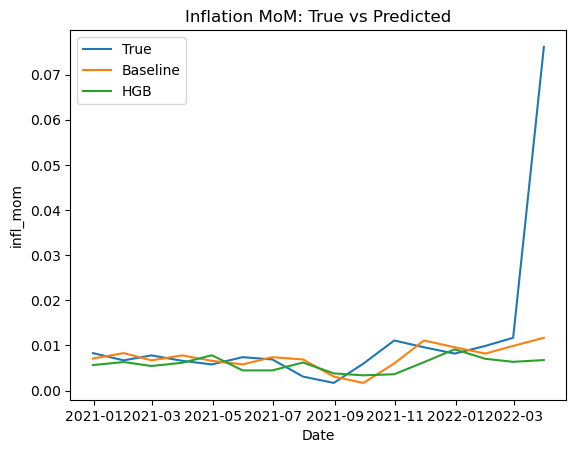

In [6]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor

target = "infl_mom"

X = model_df2.drop(columns=[target])
y = model_df2[target]

# time split: 80% train, 20% test
split_idx = int(len(model_df2) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("Train:", X_train.index.min().date(), "->", X_train.index.max().date(), "|", len(X_train))
print("Test :", X_test.index.min().date(), "->", X_test.index.max().date(), "|", len(X_test))

# baseline = прошлый месяц
baseline_pred = model_df2.loc[X_test.index, "infl_mom_lag1"]

def metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

rows = []
rows.append(("Baseline (lag1)",) + metrics(y_test, baseline_pred))

ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train, y_train)
rows.append(("Ridge",) + metrics(y_test, ridge.predict(X_test)))

hgb = HistGradientBoostingRegressor(random_state=42, max_depth=4, learning_rate=0.08, max_iter=600)
hgb.fit(X_train, y_train)
pred_hgb = hgb.predict(X_test)
rows.append(("HistGradientBoosting",) + metrics(y_test, pred_hgb))

results2 = pd.DataFrame(rows, columns=["model", "MAE", "RMSE", "R2"])
display(results2)

# график
import matplotlib.pyplot as plt
plt.figure()
plt.plot(y_test.index, y_test.values, label="True")
plt.plot(y_test.index, baseline_pred.values, label="Baseline")
plt.plot(y_test.index, pred_hgb, label="HGB")
plt.title("Inflation MoM: True vs Predicted")
plt.xlabel("Date")
plt.ylabel("infl_mom")
plt.legend()
plt.show()

In [7]:
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

target = "infl_mom"

X = model_df2.drop(columns=[target])
y = model_df2[target]

# сколько месяцев минимум нужно для старта обучения
min_train = 36  # 3 года

pred_base = []
pred_hgb = []
true_vals = []
dates = []

for i in range(min_train, len(model_df2)):
    X_train = X.iloc[:i]
    y_train = y.iloc[:i]
    X_next  = X.iloc[i:i+1]
    y_next  = y.iloc[i]

    # baseline = прошлый месяц
    base = model_df2.iloc[i]["infl_mom_lag1"]

    # HGB
    hgb = HistGradientBoostingRegressor(random_state=42, max_depth=4, learning_rate=0.08, max_iter=600)
    hgb.fit(X_train, y_train)
    phgb = hgb.predict(X_next)[0]

    pred_base.append(base)
    pred_hgb.append(phgb)
    true_vals.append(y_next)
    dates.append(model_df2.index[i])

wf = pd.DataFrame({
    "date": dates,
    "true": true_vals,
    "baseline": pred_base,
    "hgb": pred_hgb
}).set_index("date")

mae_base = mean_absolute_error(wf["true"], wf["baseline"])
mae_hgb  = mean_absolute_error(wf["true"], wf["hgb"])

print("Walk-forward MAE")
print("Baseline:", round(mae_base, 6))
print("HGB     :", round(mae_hgb, 6))

wf.tail(10)

Walk-forward MAE
Baseline: 0.003526
HGB     : 0.003826


,true,baseline,hgb
date,,,
2021-06-30,0.006900,0.007400,0.005483
2021-07-31,0.003100,0.006900,0.007182
2021-08-31,0.001700,0.003100,0.003220
2021-09-30,0.006001,0.001700,0.002473
2021-10-31,0.011100,0.006001,0.005462
2021-11-30,0.009600,0.011100,0.007289
2021-12-31,0.008200,0.009600,0.009428
2022-01-31,0.009900,0.008200,0.007667
2022-02-28,0.011700,0.009900,0.008640


In [8]:
import os
BASE = r"D:\projects\macro_inflation_project"
FIG_DIR = os.path.join(BASE, "figures")
NOTE_DIR = os.path.join(BASE, "notebooks")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(NOTE_DIR, exist_ok=True)
print("Created:", BASE)
print("figures:", FIG_DIR)

Created: D:\projects\macro_inflation_project
figures: D:\projects\macro_inflation_project\figures


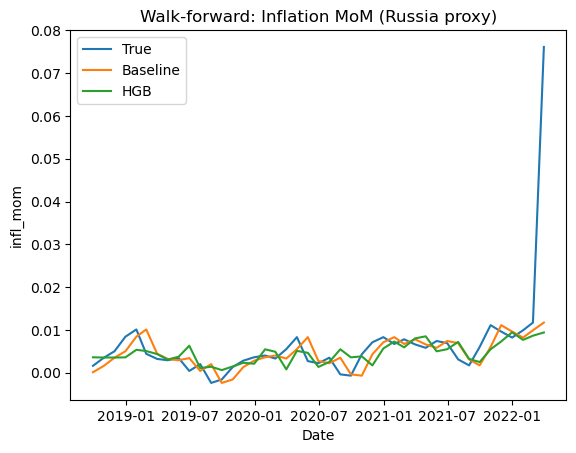

Saved: D:\projects\macro_inflation_project\figures\walkforward_infl_mom.png


In [9]:
import matplotlib.pyplot as plt
import os

plt.figure()
plt.plot(wf.index, wf["true"], label="True")
plt.plot(wf.index, wf["baseline"], label="Baseline")
plt.plot(wf.index, wf["hgb"], label="HGB")
plt.title("Walk-forward: Inflation MoM (Russia proxy)")
plt.xlabel("Date")
plt.ylabel("infl_mom")
plt.legend()

path_png = os.path.join(FIG_DIR, "walkforward_infl_mom.png")
plt.savefig(path_png, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", path_png)

In [10]:
import os
import pandas as pd

wf.to_csv(os.path.join(FIG_DIR, "walkforward_predictions.csv"))

metrics = pd.DataFrame({
    "metric": ["MAE"],
    "baseline": [mae_base],
    "hgb": [mae_hgb],
})
metrics.to_csv(os.path.join(FIG_DIR, "walkforward_metrics.csv"), index=False)

print("Saved files:", os.listdir(FIG_DIR))

Saved files: ['walkforward_infl_mom.png', 'walkforward_metrics.csv', 'walkforward_predictions.csv']
